# 📌 Outlier Detection using Z-Score Method

## 🎯 Objective

In this notebook, we will learn how to detect and remove outliers using the **Z-Score Method**.

---

## 📚 What is an Outlier?

An **outlier** is a data point that is significantly different from the rest of the observations in a dataset.

Outliers may occur due to:
- Data entry errors
- Measurement errors
- Natural variation
- Rare events

---

## ❓ Why Detect Outliers?

Outliers can:

- Affect the mean and standard deviation.
- Reduce the performance of Machine Learning models.
- Produce misleading statistical analysis.
- Influence regression models significantly.

Therefore, identifying and handling outliers is an important step in data preprocessing.

---

## 📖 What is the Z-Score Method?

The **Z-Score** measures how many standard deviations a data point is away from the mean of the dataset.

It is suitable for data that follows an approximately **Normal (Gaussian) Distribution**.

---

## 📌 Rule for Detecting Outliers

A data point is considered an outlier if:

**|Z-Score| > 3**

This rule is based on the Empirical Rule (68–95–99.7 Rule), where approximately **99.7%** of data lies within three standard deviations from the mean.

---

## 🎯 Goals of this Notebook

- Import the required libraries
- Load the Titanic dataset
- Understand the numerical features
- Check whether the data is normally distributed
- Calculate Z-Scores
- Detect outliers
- Remove outliers
- Compare the dataset before and after removing outliers

In [1]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df = df[['Age']]
df.head()

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

,0
Age,0


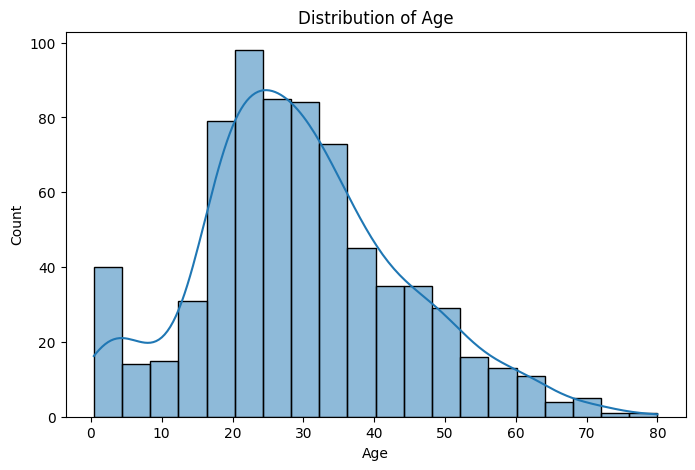

In [9]:
# @title
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title("Distribution of Age")
plt.show()

In [10]:
print("Mean :", df['Age'].mean())
print("Standard Deviation :", df['Age'].std())

Mean : 29.69911764705882
Standard Deviation : 14.526497332334044


## ✂️ Trimming (Removing Outliers)

### What is Trimming?

**Trimming** is the process of **removing the rows** that contain outliers from the dataset.

Instead of modifying the outlier values, we completely remove those observations.

---

### When Should We Use Trimming?

- When the dataset is large.
- When outliers are caused by errors or incorrect measurements.
- When removing a few observations will not affect the overall dataset.

---

### Advantages

- Removes extreme values completely.
- Improves the performance of many Machine Learning models.
- Makes the dataset cleaner.

---

### Disadvantages

- Data loss occurs.
- Important information may be removed if the outlier is genuine.
- Not suitable for small datasets.

---

### In this notebook

We will detect outliers using the **Z-Score Method** and remove all rows where:

**|Z-Score| > 3**

In [11]:
from scipy import stats

df['z_score'] = stats.zscore(df['Age'])

In [12]:
df.head()

,Age,z_score
0,22.0,-0.530377
1,38.0,0.571831
2,26.0,-0.254825
3,35.0,0.365167
4,35.0,0.365167


In [13]:
df.head()

,Age,z_score
0,22.0,-0.530377
1,38.0,0.571831
2,26.0,-0.254825
3,35.0,0.365167
4,35.0,0.365167


In [14]:
df[(df['z_score'] > 3) | (df['z_score'] < -3)]

,Age,z_score
630,80.0,3.465126
851,74.0,3.051798


In [15]:
df[(df['z_score'] > 3) | (df['z_score'] < -3)].shape

(2, 2)

In [16]:
df_trimmed = df[(df['z_score'] < 3) & (df['z_score'] > -3)]

In [17]:
print("Original Shape :", df.shape)
print("Trimmed Shape :", df_trimmed.shape)

Original Shape : (714, 2)
Trimmed Shape : (712, 2)


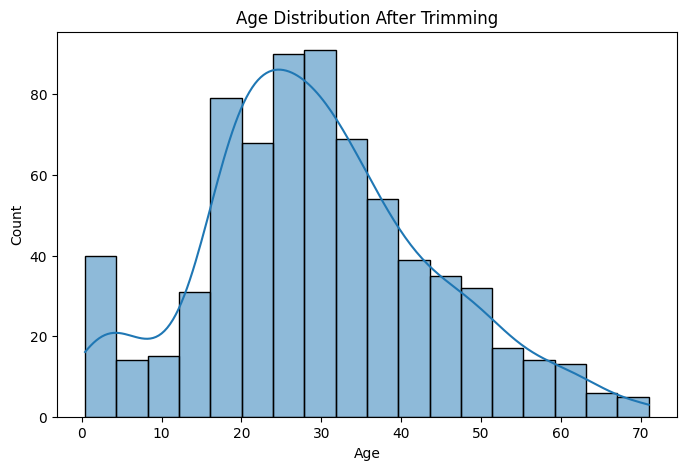

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df_trimmed['Age'], kde=True)
plt.title("Age Distribution After Trimming")
plt.show()

## 📌 Capping (Winsorization)

### What is Capping?

**Capping** is the process of **replacing extreme outlier values with a threshold value** instead of removing them.

The rows remain in the dataset, but their extreme values are limited.

---

### When Should We Use Capping?

- When the dataset is small.
- When we do not want to lose observations.
- When outliers are genuine but too extreme.

---

### Advantages

- No data loss.
- Preserves the number of observations.
- Reduces the influence of extreme values.

---

### Disadvantages

- Outliers are not removed completely.
- May introduce slight bias into the data.
- Threshold selection is important.

---

### In this notebook

After detecting outliers using the **Z-Score Method**, we will replace values outside the acceptable range with the lower and upper threshold values instead of deleting the rows.

In [19]:
upper_limit = df['Age'].mean() + 3 * df['Age'].std()
lower_limit = df['Age'].mean() - 3 * df['Age'].std()

print("Upper Limit:", upper_limit)
print("Lower Limit:", lower_limit)

Upper Limit: 73.27860964406095
Lower Limit: -13.88037434994331


In [20]:
df_capped = df.copy()

df_capped['Age'] = np.where(
    df_capped['Age'] > upper_limit,
    upper_limit,
    np.where(
        df_capped['Age'] < lower_limit,
        lower_limit,
        df_capped['Age']
    )
)

In [21]:
df_capped.head()

,Age,z_score
0,22.0,-0.530377
1,38.0,0.571831
2,26.0,-0.254825
3,35.0,0.365167
4,35.0,0.365167


In [22]:
print("Maximum Age Before:", df['Age'].max())
print("Maximum Age After :", df_capped['Age'].max())

print("Minimum Age Before:", df['Age'].min())
print("Minimum Age After :", df_capped['Age'].min())

Maximum Age Before: 80.0
Maximum Age After : 73.27860964406095
Minimum Age Before: 0.42
Minimum Age After : 0.42


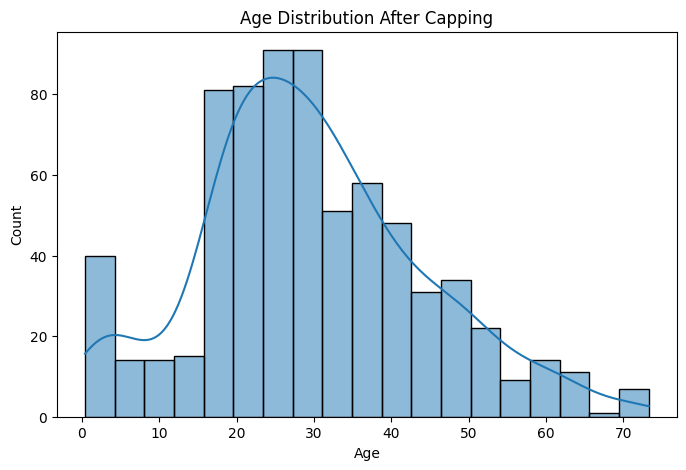

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df_capped['Age'], kde=True)
plt.title("Age Distribution After Capping")
plt.show()